# Composable Diffusion: Multi-Condition Generation

This notebook demonstrates **Composable Diffusion** — generating samples that satisfy multiple conditions simultaneously.

**Core Formula:**
$$D_{combo} = D_{x_1} + D_{x_2} - D_{uncond}$$

**Interpretation:**
- $D_{x_1}$: Denoiser conditioned on attribute 1 (e.g., horizontal position)
- $D_{x_2}$: Denoiser conditioned on attribute 2 (e.g., vertical position)
- $D_{uncond}$: Unconditional denoiser (subtracted to avoid double-counting the prior)

**Setup:**
- **Data**: Quadrant dataset (4 clusters in 4 quadrants)
- **Attribute A**: Vertical position (0=top, 1=bottom)
- **Attribute B**: Horizontal position (0=left, 1=right)
- **Goal**: Generate samples satisfying A AND B

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from acg import get_sigmas_karras
from acg.samplers import sample_heun_multi_attr
from acg.denoisers import MultiAttributeDenoiser
from acg.datasets import make_quadrant_dataset, make_gaussian_mixture

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Create Quadrant Dataset

4 Gaussian clusters in 4 quadrants, with two independent attributes:

| Quadrant | Attr A (vertical) | Attr B (horizontal) | Position |
|----------|-------------------|---------------------|----------|
| Q0 | 0 (top) | 0 (left) | Top-Left |
| Q1 | 0 (top) | 1 (right) | Top-Right |
| Q2 | 1 (bottom) | 0 (left) | Bottom-Left |
| Q3 | 1 (bottom) | 1 (right) | Bottom-Right |

In [2]:
# Create Quadrant dataset
n_samples_per_quadrant = 200
data, labels_A, labels_B = make_quadrant_dataset(
    n_samples_per_class=n_samples_per_quadrant,
    spread=2.0,
    std=0.4
)
data = data.to(device)
labels_A = labels_A.to(device)
labels_B = labels_B.to(device)

print(f"Data shape: {data.shape}")
print(f"Attribute A (vertical): {labels_A.unique().tolist()} (0=top, 1=bottom)")
print(f"Attribute B (horizontal): {labels_B.unique().tolist()} (0=left, 1=right)")

Data shape: torch.Size([800, 2])
Attribute A (vertical): [0, 1] (0=top, 1=bottom)
Attribute B (horizontal): [0, 1] (0=left, 1=right)


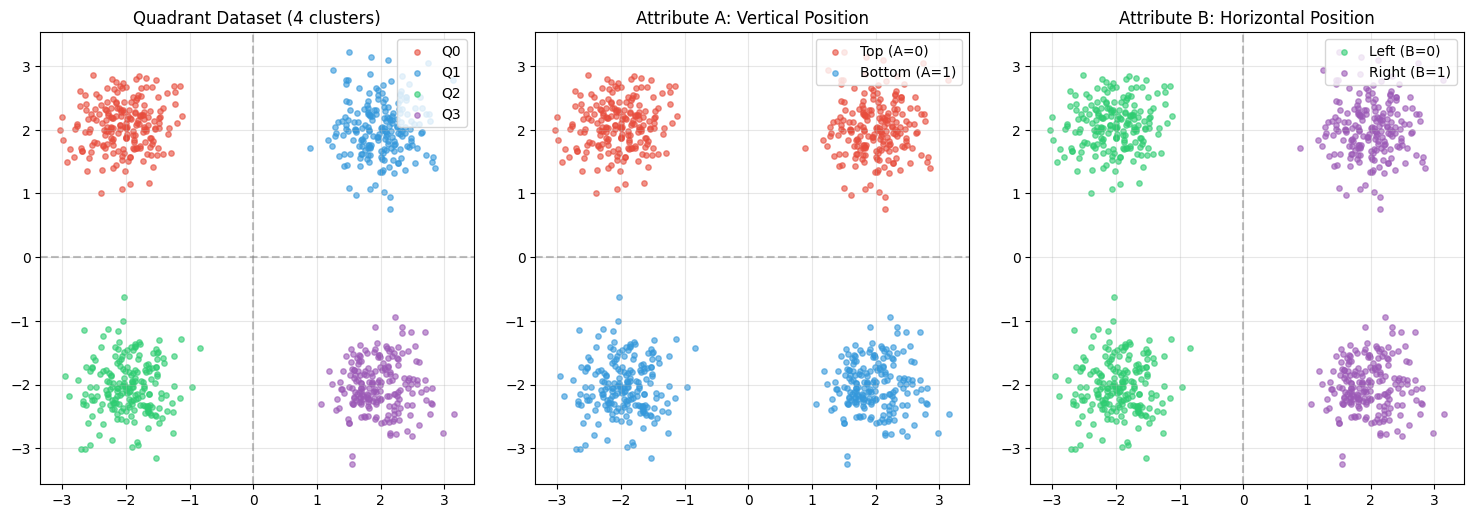

In [3]:
# Visualize Quadrant dataset
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

data_np = data.cpu().numpy()
labels_A_np = labels_A.cpu().numpy()
labels_B_np = labels_B.cpu().numpy()

# Combined quadrant view
ax = axes[0]
quadrant_labels = labels_A_np * 2 + labels_B_np  # 0, 1, 2, 3
colors_quad = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']  # TL, TR, BL, BR
for q in range(4):
    mask = quadrant_labels == q
    ax.scatter(data_np[mask, 0], data_np[mask, 1], c=colors_quad[q], alpha=0.6, s=15,
               label=f'Q{q}')
ax.set_title('Quadrant Dataset (4 clusters)', fontsize=12)
ax.legend(loc='upper right')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# Attribute A view (vertical: top/bottom)
ax = axes[1]
colors_A = ['#E74C3C', '#3498DB']  # top=red, bottom=blue
for a in [0, 1]:
    mask = labels_A_np == a
    label = 'Top (A=0)' if a == 0 else 'Bottom (A=1)'
    ax.scatter(data_np[mask, 0], data_np[mask, 1], c=colors_A[a], alpha=0.6, s=15, label=label)
ax.set_title('Attribute A: Vertical Position', fontsize=12)
ax.legend(loc='upper right')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Attribute B view (horizontal: left/right)
ax = axes[2]
colors_B = ['#2ECC71', '#9B59B6']  # left=green, right=purple
for b in [0, 1]:
    mask = labels_B_np == b
    label = 'Left (B=0)' if b == 0 else 'Right (B=1)'
    ax.scatter(data_np[mask, 0], data_np[mask, 1], c=colors_B[b], alpha=0.6, s=15, label=label)
ax.set_title('Attribute B: Horizontal Position', fontsize=12)
ax.legend(loc='upper right')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 2. Setup Multi-Attribute Denoiser

In [4]:
# Create Multi-Attribute Denoiser
denoiser = MultiAttributeDenoiser(
    data=data,
    attributes=[labels_A, labels_B],
    attribute_names=["A", "B"]  # A=vertical, B=horizontal
)

print(f"Multi-Attribute Denoiser created")
print(f"  - Attributes: {denoiser.attribute_names}")
print(f"  - Data points: {denoiser.data.shape[0]}")

Multi-Attribute Denoiser created
  - Attributes: ['A', 'B']
  - Data points: 800


In [5]:
# Noise schedule and initial latents
n_steps = 50
sigma_min = 0.01
sigma_max = 5.0

sigmas = get_sigmas_karras(
    n_steps=n_steps,
    sigma_min=sigma_min,
    sigma_max=sigma_max,
    device=device
)

# 8 Gaussians as initial distribution
n_samples = 64
init_data, init_labels = make_gaussian_mixture(
    n_samples_per_class=n_samples // 8,
    n_classes=8,
    spread=1.0,
    std=0.15
)
init_data = init_data.to(device)
latents = (init_data * sigmas[0]).to(device)

print(f"Initial latents: {latents.shape}")

Initial latents: torch.Size([64, 2])


## 3. Single Attribute Conditioning

First, demonstrate single-attribute conditioning:
- Condition on A=0 (top) only → generates top-left AND top-right
- Condition on B=1 (right) only → generates top-right AND bottom-right

In [6]:
# Single attribute: A=0 (top)
traj_A0 = sample_heun_multi_attr(
    denoiser, latents, sigmas,
    attr_conditions={"A": 0},
    return_trajectory=True
)
print(f"Condition A=0 (top): {traj_A0.shape}")

# Single attribute: B=1 (right)
traj_B1 = sample_heun_multi_attr(
    denoiser, latents, sigmas,
    attr_conditions={"B": 1},
    return_trajectory=True
)
print(f"Condition B=1 (right): {traj_B1.shape}")

Condition A=0 (top): torch.Size([64, 51, 2])
Condition B=1 (right): torch.Size([64, 51, 2])


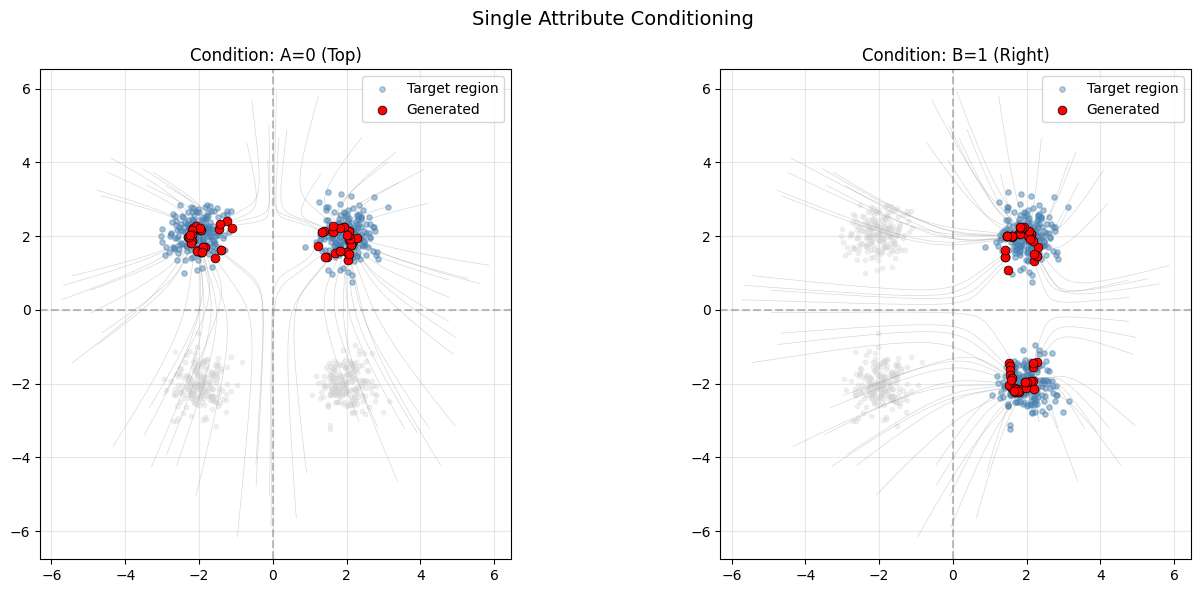

In [7]:
# Visualize single-attribute results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (traj, title, highlight_mask) in enumerate([
    (traj_A0, 'Condition: A=0 (Top)', labels_A_np == 0),
    (traj_B1, 'Condition: B=1 (Right)', labels_B_np == 1)
]):
    ax = axes[idx]
    traj_np = traj.cpu().numpy()
    
    # Background: all data in light gray
    ax.scatter(data_np[:, 0], data_np[:, 1], c='lightgray', alpha=0.3, s=10)
    
    # Highlight matching data
    ax.scatter(data_np[highlight_mask, 0], data_np[highlight_mask, 1],
               c='steelblue', alpha=0.4, s=15, label='Target region')
    
    # Plot trajectories
    for i in range(traj_np.shape[0]):
        ax.plot(traj_np[i, :, 0], traj_np[i, :, 1], '-', color='gray', alpha=0.3, linewidth=0.5)
    
    # Final samples
    ax.scatter(traj_np[:, -1, 0], traj_np[:, -1, 1],
               c='red', s=40, edgecolors='black', linewidth=0.5, label='Generated', zorder=5)
    
    ax.set_title(title, fontsize=12)
    ax.legend(loc='upper right')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

fig.suptitle('Single Attribute Conditioning', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Composable Diffusion: A AND B

Now the key demonstration: combine two conditions using
$$D_{combo} = D_{A=0} + D_{B=1} - D_{uncond}$$

This should generate samples in the **top-right quadrant only** (satisfying both A=0 AND B=1).

In [8]:
# Composable: A=0 AND B=1 (top-right)
traj_A0_B1 = sample_heun_multi_attr(
    denoiser, latents, sigmas,
    attr_conditions={"A": 0, "B": 1},  # Both conditions
    return_trajectory=True
)
print(f"Condition A=0 AND B=1 (top-right): {traj_A0_B1.shape}")

Condition A=0 AND B=1 (top-right): torch.Size([64, 51, 2])


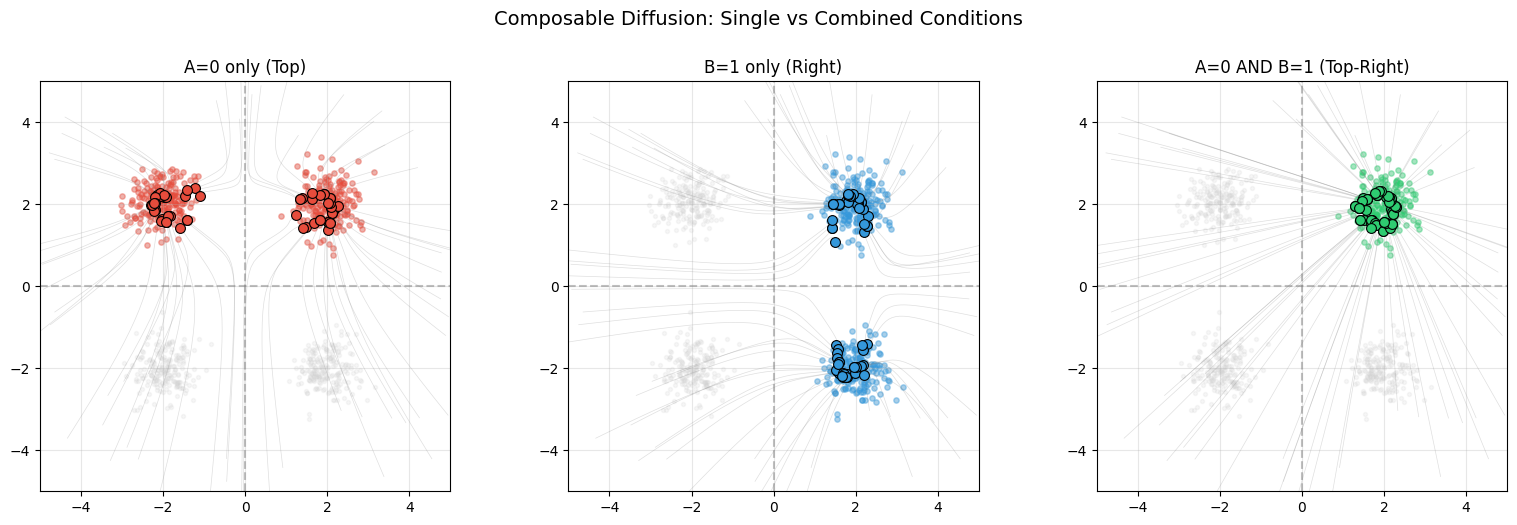

In [9]:
# Compare: Single A, Single B, Composed A+B
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = [
    (traj_A0, 'A=0 only (Top)', labels_A_np == 0, '#E74C3C'),
    (traj_B1, 'B=1 only (Right)', labels_B_np == 1, '#3498DB'),
    (traj_A0_B1, 'A=0 AND B=1 (Top-Right)', (labels_A_np == 0) & (labels_B_np == 1), '#2ECC71')
]

for idx, (traj, title, highlight_mask, color) in enumerate(configs):
    ax = axes[idx]
    traj_np = traj.cpu().numpy()
    
    # Background data
    ax.scatter(data_np[:, 0], data_np[:, 1], c='lightgray', alpha=0.2, s=8)
    
    # Target region
    ax.scatter(data_np[highlight_mask, 0], data_np[highlight_mask, 1],
               c=color, alpha=0.4, s=15)
    
    # Trajectories
    for i in range(traj_np.shape[0]):
        ax.plot(traj_np[i, :, 0], traj_np[i, :, 1], '-', color='gray', alpha=0.25, linewidth=0.5)
    
    # Final samples
    ax.scatter(traj_np[:, -1, 0], traj_np[:, -1, 1],
               c=color, s=50, edgecolors='black', linewidth=0.8, zorder=5)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

fig.suptitle('Composable Diffusion: Single vs Combined Conditions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. All 4 Quadrant Combinations

Generate samples for all possible (A, B) combinations to verify composability.

In [10]:
# Generate all 4 combinations
combinations = [
    ({"A": 0, "B": 0}, "Top-Left (A=0, B=0)"),
    ({"A": 0, "B": 1}, "Top-Right (A=0, B=1)"),
    ({"A": 1, "B": 0}, "Bottom-Left (A=1, B=0)"),
    ({"A": 1, "B": 1}, "Bottom-Right (A=1, B=1)"),
]

results = {}
for cond, name in combinations:
    traj = sample_heun_multi_attr(
        denoiser, latents, sigmas,
        attr_conditions=cond,
        return_trajectory=True
    )
    results[name] = traj
    print(f"{name}: done")

Top-Left (A=0, B=0): done
Top-Right (A=0, B=1): done
Bottom-Left (A=1, B=0): done
Bottom-Right (A=1, B=1): done


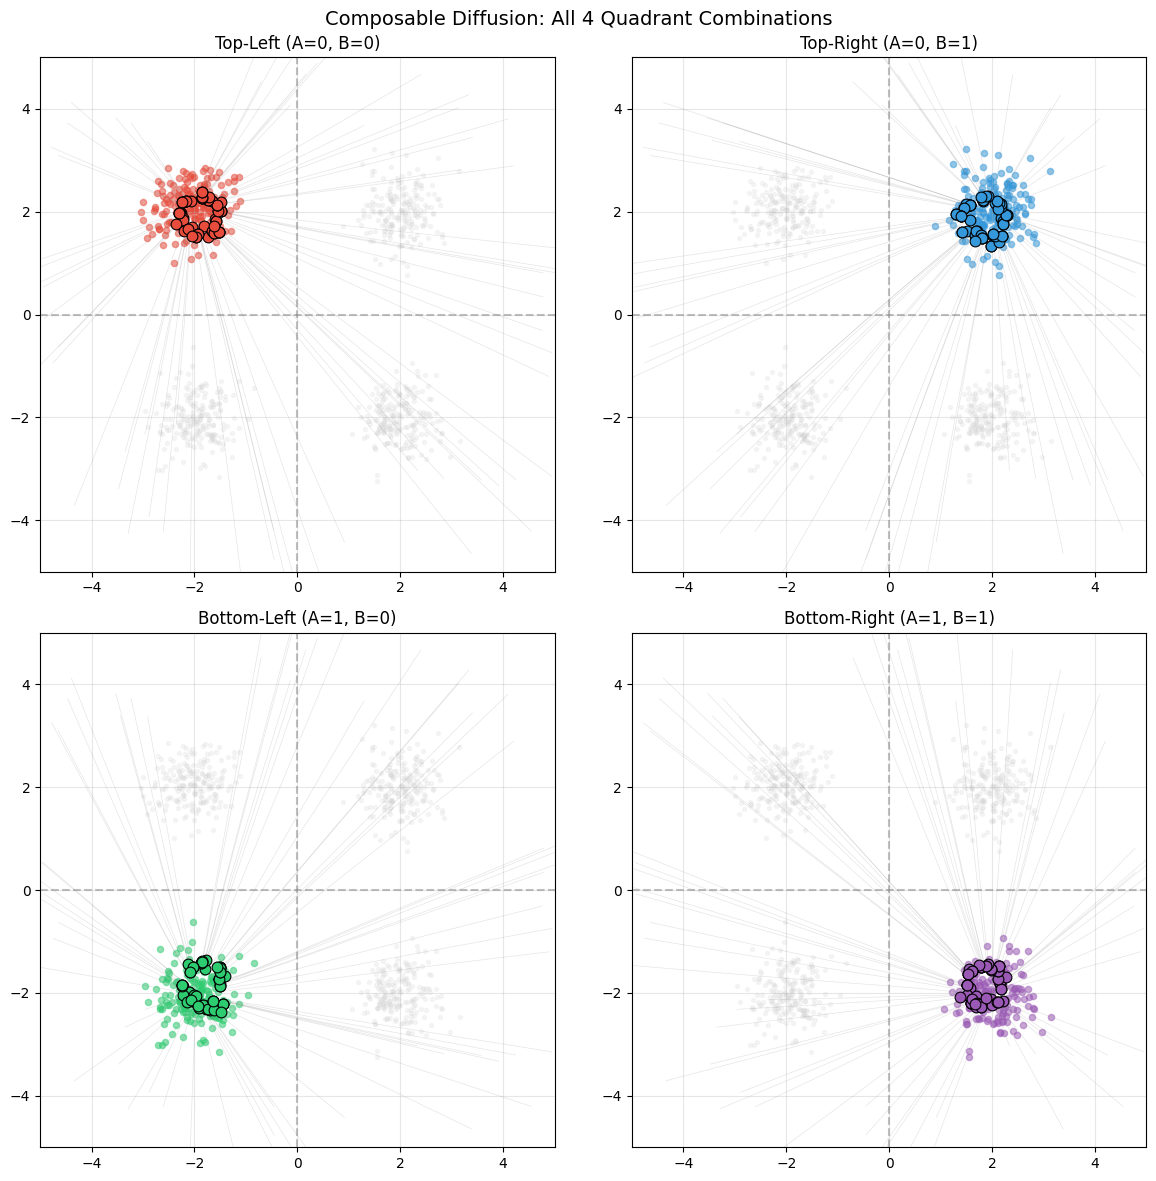

In [11]:
# Visualize all 4 combinations
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

quadrant_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]  # TL, TR, BL, BR

for idx, ((cond, name), pos) in enumerate(zip(combinations, positions)):
    ax = axes[pos[0], pos[1]]
    traj_np = results[name].cpu().numpy()
    
    a_val, b_val = cond["A"], cond["B"]
    highlight_mask = (labels_A_np == a_val) & (labels_B_np == b_val)
    
    # Background
    ax.scatter(data_np[:, 0], data_np[:, 1], c='lightgray', alpha=0.2, s=8)
    
    # Target quadrant
    ax.scatter(data_np[highlight_mask, 0], data_np[highlight_mask, 1],
               c=quadrant_colors[idx], alpha=0.5, s=20)
    
    # Trajectories
    for i in range(traj_np.shape[0]):
        ax.plot(traj_np[i, :, 0], traj_np[i, :, 1], '-', color='gray', alpha=0.2, linewidth=0.5)
    
    # Final samples
    ax.scatter(traj_np[:, -1, 0], traj_np[:, -1, 1],
               c=quadrant_colors[idx], s=60, edgecolors='black', linewidth=0.8, zorder=5)
    
    ax.set_title(name, fontsize=12)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

fig.suptitle('Composable Diffusion: All 4 Quadrant Combinations', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Guidance Scale Effect on Composition

In [12]:
# Test different guidance scales for composed condition
guidance_configs = [
    ({"A": 1.0, "B": 1.0}, "w=1.0, 1.0"),
    ({"A": 2.0, "B": 2.0}, "w=2.0, 2.0"),
    ({"A": 3.0, "B": 3.0}, "w=3.0, 3.0"),
    ({"A": 1.0, "B": 3.0}, "w=1.0, 3.0 (B stronger)"),
]

target_cond = {"A": 0, "B": 1}  # Top-right

guidance_results = {}
for scales, name in guidance_configs:
    traj = sample_heun_multi_attr(
        denoiser, latents, sigmas,
        attr_conditions=target_cond,
        guidance_scales=scales,
        return_trajectory=True
    )
    guidance_results[name] = traj
    print(f"{name}: done")

w=1.0, 1.0: done
w=2.0, 2.0: done
w=3.0, 3.0: done
w=1.0, 3.0 (B stronger): done


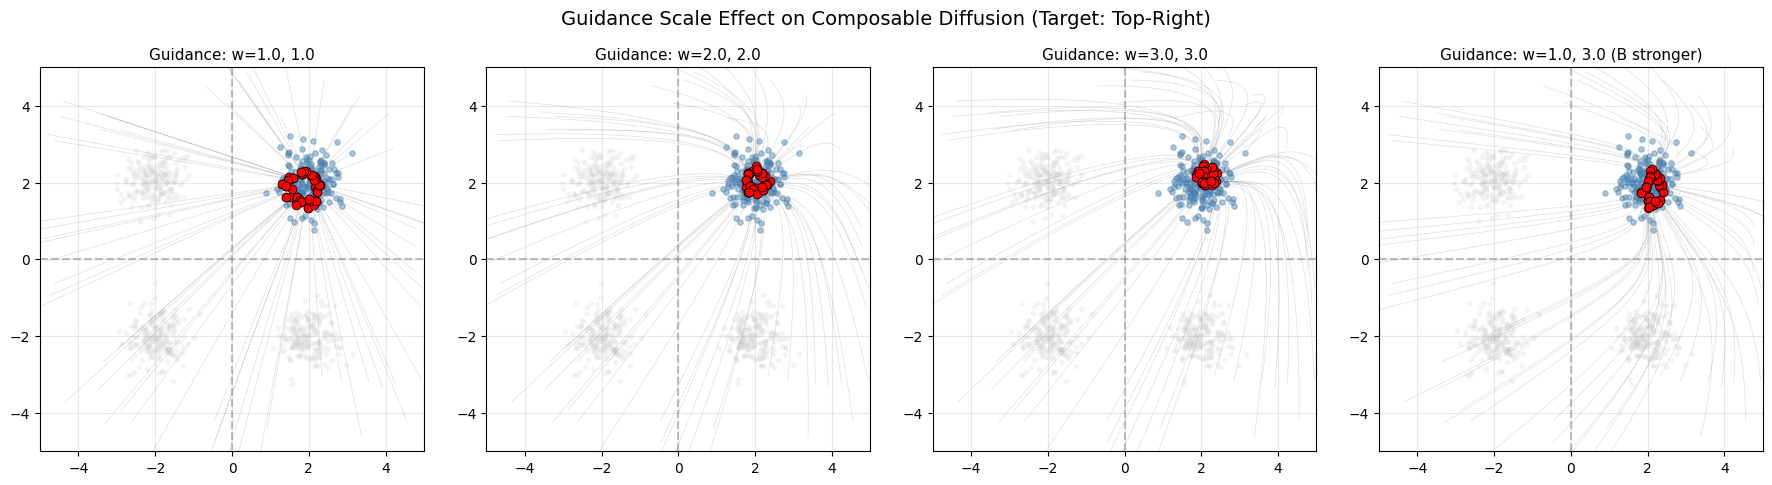

In [13]:
# Visualize guidance scale effect
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

highlight_mask = (labels_A_np == 0) & (labels_B_np == 1)  # Top-right

for idx, (scales, name) in enumerate(guidance_configs):
    ax = axes[idx]
    traj_np = guidance_results[name].cpu().numpy()
    
    # Background
    ax.scatter(data_np[:, 0], data_np[:, 1], c='lightgray', alpha=0.2, s=8)
    
    # Target
    ax.scatter(data_np[highlight_mask, 0], data_np[highlight_mask, 1],
               c='steelblue', alpha=0.4, s=15)
    
    # Trajectories
    for i in range(traj_np.shape[0]):
        ax.plot(traj_np[i, :, 0], traj_np[i, :, 1], '-', color='gray', alpha=0.25, linewidth=0.5)
    
    # Final
    ax.scatter(traj_np[:, -1, 0], traj_np[:, -1, 1],
               c='red', s=40, edgecolors='black', linewidth=0.5, zorder=5)
    
    ax.set_title(f'Guidance: {name}', fontsize=11)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

fig.suptitle('Guidance Scale Effect on Composable Diffusion (Target: Top-Right)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Vector Field Visualization

Compare vector fields: Unconditional vs Single-condition vs Composed

In [14]:
def plot_attr_vector_field(denoiser, sigma, attr_conditions, guidance_scales, ax, title):
    """Plot vector field for given attribute conditions."""
    xlim, ylim = (-4, 4), (-4, 4)
    grid_size = 16
    
    x = torch.linspace(xlim[0], xlim[1], grid_size, device=device)
    y = torch.linspace(ylim[0], ylim[1], grid_size, device=device)
    xx, yy = torch.meshgrid(x, y, indexing='xy')
    grid_points = torch.stack([xx.flatten(), yy.flatten()], dim=1)
    
    sigma_batch = torch.full((grid_points.shape[0],), sigma, device=device)
    
    denoised = denoiser(
        grid_points, sigma_batch,
        attr_conditions=attr_conditions,
        guidance_scales=guidance_scales
    )
    
    displacement = (denoised - grid_points).cpu().numpy()
    grid_np = grid_points.cpu().numpy()
    
    # Plot data
    ax.scatter(data_np[:, 0], data_np[:, 1], c='lightgray', alpha=0.3, s=8)
    
    # Vector field
    ax.quiver(
        grid_np[:, 0], grid_np[:, 1],
        displacement[:, 0], displacement[:, 1],
        alpha=0.7, color='darkblue', scale=25
    )
    
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

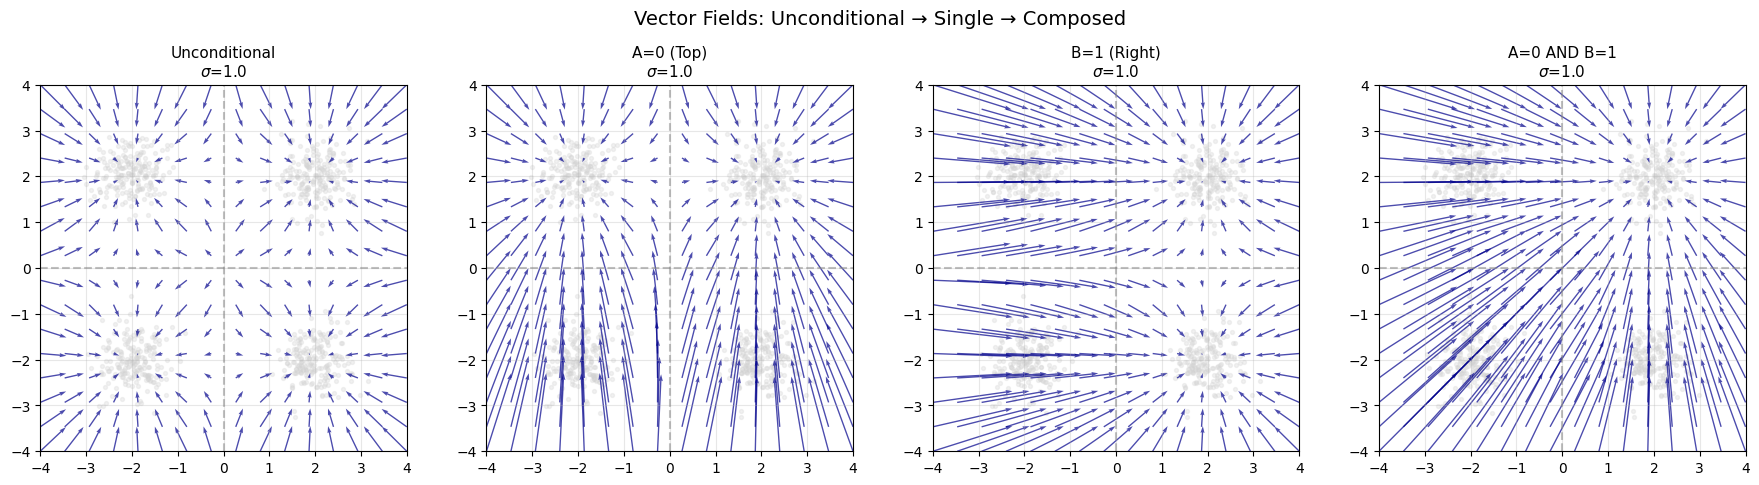

In [15]:
# Compare vector fields
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
sigma_vis = 1.0

configs = [
    (None, None, 'Unconditional'),
    ({"A": 0}, None, 'A=0 (Top)'),
    ({"B": 1}, None, 'B=1 (Right)'),
    ({"A": 0, "B": 1}, None, 'A=0 AND B=1'),
]

for idx, (cond, scales, title) in enumerate(configs):
    plot_attr_vector_field(denoiser, sigma_vis, cond, scales, axes[idx], f'{title}\n$\\sigma$={sigma_vis}')

fig.suptitle('Vector Fields: Unconditional → Single → Composed', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Summary

**Composable Diffusion** enables generating samples that satisfy multiple conditions simultaneously:

$$D_{combo} = D_{uncond} + \sum_i w_i \cdot (D_{c_i} - D_{uncond})$$

When $w_i = 1$ for all conditions:
$$D_{combo} = D_{c_1} + D_{c_2} - D_{uncond}$$

**Key Observations:**
1. Single-condition generation covers multiple quadrants (e.g., A=0 → both top quadrants)
2. Composed conditions narrow down to the intersection (A=0 AND B=1 → top-right only)
3. Guidance scales can weight conditions differently
4. Vector fields clearly show how composition "steers" toward the intersection

In [16]:
print("Composable Diffusion demo complete!")
print(f"  - Dataset: Quadrant (4 clusters, 2 attributes)")
print(f"  - Denoiser: MultiAttributeDenoiser")
print(f"  - Sampler: sample_heun_multi_attr")
print(f"  - Formula: D_combo = D_A + D_B - D_uncond")

Composable Diffusion demo complete!
  - Dataset: Quadrant (4 clusters, 2 attributes)
  - Denoiser: MultiAttributeDenoiser
  - Sampler: sample_heun_multi_attr
  - Formula: D_combo = D_A + D_B - D_uncond
